[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/05_machine_learning/A5_conformal_prediction.ipynb)

> 📎 **Appendix notebook — reference style.** This is one of the optional appendices (see `README.md`). Unlike the main course notebooks, appendices are written as a demo / reference: they focus on *seeing* an idea at work rather than on interactive exercises. You won't find the full Solution / Debug-me / Self-assessment scaffolding here. This appendix runs end-to-end on the **core course stack** (`numpy`, `scikit-learn`, `scipy`) — every method is implemented *from scratch* so nothing extra is required. The specialist libraries (**MAPIE**, **crepes**, …) appear as **reference code** you can copy once installed.

---
# 📓 Notebook A5 (ML) — Conformal Prediction: Distribution-Free Uncertainty

> **Module:** Machine Learning · **Type:** Appendix · **Estimated time:** 60–75 min · **Difficulty:** Intermediate → Advanced

Notebook 18 taught you to *evaluate* a model and to *calibrate* its probabilities. But a calibrated classifier still only tells you `P(churn) = 0.71`, and a regressor still hands back a single number — `delivery in 38 minutes` — with **no honest error bar**. "How wrong could this be, and can you *guarantee* it?" is the question the business actually asks before it acts on a prediction.

**Conformal prediction** answers exactly that. It is a thin wrapper around *any* trained model that turns point predictions into **prediction intervals** (regression) or **prediction sets** (classification) with a **finite-sample coverage guarantee** — e.g. "the true value lands in this band ≥ 90% of the time" — with **no assumption** about the model or the data distribution beyond *exchangeability*. No Gaussian residuals, no asymptotics, no retraining.

This appendix builds the method up from one idea, proves the guarantee empirically, and then shows the production libraries.

---

## 🎯 Learning objectives
- State the conformal guarantee and the **one** assumption it rests on (exchangeability).
- Implement **split (inductive) conformal** regression and classification *from scratch* — and prove the coverage holds.
- Make intervals **adaptive** to local difficulty with **CQR** (conformalized quantile regression).
- Read **prediction sets** in classification as an *honesty* signal (set size = ambiguity).
- Handle the case the guarantee *breaks*: **time series & distribution shift** (ACI / EnbPI).
- Map the idea to the libraries you'd actually reach for: **MAPIE**, **crepes**, **puncc**, **TorchCP**.

## ✅ Prerequisites
- Notebook 17 (sklearn basics) and **Notebook 18 (model evaluation & calibration)** — conformal is the guarantee calibration *can't* give you.
- Notebook 11 (time series) helps for §5.

## 📦 Install (optional — only for the reference cells)

```bash
pip install mapie          # the de-facto standard; sklearn-compatible
pip install crepes         # lightweight, fast, research-friendly
# pip install puncc        # Deel's predictive-uncertainty library
# pip install torchcp      # conformal for PyTorch / deep learning
```

## 1. The problem — a point prediction is a guess with no guarantee

Notebook 18 ended on **calibration**: making `predict_proba` mean what it says. That is necessary but not sufficient:

| What you have | What it tells you | What it does **not** tell you |
|---|---|---|
| `model.predict(X) → 38` (regression) | the single best guess | how far off it could be |
| `predict_proba(X) → 0.71` (classification) | a (hopefully calibrated) probability | a *set* of plausible labels with a guarantee |
| `±1.96·σ` from residual std | a band — **if** residuals are Gaussian & homoscedastic | anything trustworthy when they're not |

Calibration is about the **probabilities being right on average**. Conformal prediction is about **coverage**: building a region that contains the truth a *specified* fraction of the time, **whatever** the model and **whatever** the noise distribution. Those are different promises — and only the second one is what a decision-maker needs when a wrong call is expensive ("dispatch a second driver if the 90% upper bound on delivery time exceeds the SLA").

In [1]:
# Core stack only — everything in this notebook runs without any extra install.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(0)

# A deliberately HETEROSCEDASTIC regression problem: noise GROWS with x.
# Think "delivery-time vs distance": short trips are predictable, long ones aren't.
def make_data(n):
    x = rng.uniform(0, 10, size=n)
    noise = rng.normal(0, 0.2 + 0.2 * x)        # std rises ~11x with x  → fans out
    y = 2.0 * np.sin(x) + 0.5 * x + noise
    return x.reshape(-1, 1), y

X, y = make_data(4000)
# THREE-way split is the heart of split conformal: train / calibrate / test.
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.5, random_state=0)
X_cal, X_te, y_cal, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=0)
print(f"train {len(X_tr)} · calibrate {len(X_cal)} · test {len(X_te)}")


train 2000 · calibrate 1000 · test 1000


📈 **First, meet the data.** The noise *fans out* with `x` — short trips are easy, long ones volatile; a single fixed error bar can't capture that.

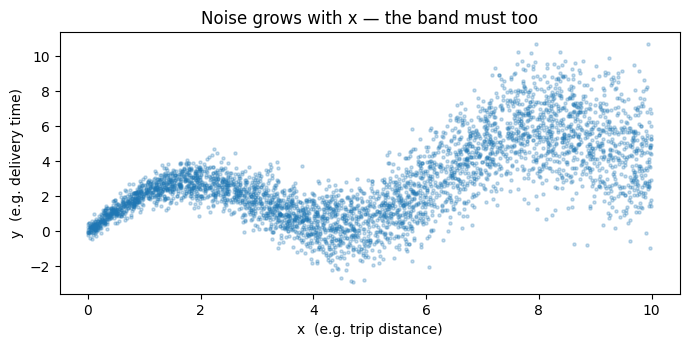

In [2]:
# A quick look at the heteroscedastic data the whole notebook builds on.
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.scatter(X.ravel(), y, s=5, alpha=0.25, color="C0")
ax.set_xlabel("x  (e.g. trip distance)"); ax.set_ylabel("y  (e.g. delivery time)")
ax.set_title("Noise grows with x — the band must too")
plt.show()

In [3]:
model = RandomForestRegressor(n_estimators=200, random_state=0).fit(X_tr, y_tr)
print("plain point-prediction R^2 on test:", round(model.score(X_te, y_te), 3))

plain point-prediction R^2 on test: 0.539


## 2. The one idea (and the one assumption)

> **Conformal prediction:** hold out a fresh **calibration set** the model never trained on. Measure how wrong the model is on it (the *nonconformity scores*). The right **quantile** of those errors becomes the half-width of an interval that, on a new point, contains the truth with probability **at least 1 − α**.

The guarantee, stated precisely (split conformal, Vovk et al.):

$$\mathbb{P}\big(\,Y_{n+1} \in \hat{C}(X_{n+1})\,\big)\;\ge\;1-\alpha$$

It holds **for any model**, **any sample size**, **any distribution** — provided one thing:

> **Exchangeability.** The calibration points and the new test point are drawn such that their *joint distribution doesn't change if you reorder them*. (I.i.d. data satisfies this; it is *weaker* than i.i.d.) This is the **whole** ballgame — when it breaks, the guarantee breaks, and §5 is about exactly that.

That's it. No Gaussianity, no "enough data for the CLT", no correctly-specified model. A *terrible* model still gets valid coverage — its intervals are just **wide** (honest about being bad). A good model gets **narrow** intervals. Coverage is guaranteed; **width is the quality metric**.

### 🔬 What actually happens — split conformal in four moves

```text
  TRAIN set ──▶  fit model  f̂                       (any model at all)
                    │
  CALIB set ──▶  scores  sᵢ = |yᵢ − f̂(xᵢ)|          (how wrong is f̂ here?)
                    │
                    ▼
        q̂ = the ⌈(n+1)(1−α)⌉ / n  quantile of the sᵢ   (a single number!)
                    │
                    ▼
  NEW x   ──▶  interval =  [ f̂(x) − q̂ ,  f̂(x) + q̂ ]
```

Read it as: *"On data I've never trained on, my typical-to-large error is q̂. So around any new prediction, ±q̂ is the band that was big enough to catch the truth (1−α) of the time on calibration — and exchangeability says the new point is no different."*

The only subtlety is that quantile **level**. You don't take the plain `1−α` quantile; you take the slightly-higher `⌈(n+1)(1−α)⌉ / n` one. That finite-sample correction is what upgrades "≈ 1−α on this sample" into the *provable* "≥ 1−α on the next point". With n = 1000 and α = 0.1 it's the 0.901 quantile instead of 0.900 — tiny, but it's the difference between a heuristic and a theorem.

In [4]:
# 🧪 PROOF — split conformal regression FROM SCRATCH, then measure coverage.
alpha = 0.10                                            # we want >= 90% coverage

def split_conformal_band(model, X_cal, y_cal, alpha):
    scores = np.abs(y_cal - model.predict(X_cal))      # nonconformity = abs residual
    n = len(scores)
    level = np.ceil((n + 1) * (1 - alpha)) / n          # finite-sample correction
    level = min(level, 1.0)
    qhat = np.quantile(scores, level, method="higher")  # the magic number
    return qhat

qhat = split_conformal_band(model, X_cal, y_cal, alpha)
pred = model.predict(X_te)
lower, upper = pred - qhat, pred + qhat

covered = (y_te >= lower) & (y_te <= upper)
print(f"half-width q̂           = {qhat:.3f}")
print(f"target coverage         = {1 - alpha:.0%}")
print(f"EMPIRICAL coverage      = {covered.mean():.1%}   <-- on data the band never saw")
print(f"average interval width  = {(upper - lower).mean():.3f}")

half-width q̂           = 2.803
target coverage         = 90%
EMPIRICAL coverage      = 91.4%   <-- on data the band never saw
average interval width  = 5.606


**That ~90% is not a coincidence and not a fit — it's the theorem.** We never assumed anything about the noise (it's heteroscedastic and definitely not constant-variance), never retrained, and used a random forest as a black box. The calibration quantile did all the work.

Two things to internalise:

1. **The finite-sample correction matters at small n.** With a 50-row calibration set and α = 0.1, `⌈51·0.9⌉/50 = 46/50 = 0.92` — you take the 92nd percentile, not the 90th. Skip it and you systematically *under*-cover on small calibration sets.
2. **Coverage is a property of the *procedure over many draws*, not of one band.** Let's see that distribution — and contrast it with the textbook Gaussian band, which is *not* distribution-free.

In [5]:
# 🧪 PROOF #2 — (a) coverage concentrates at 1-alpha over many random calibration draws,
#               (b) the Gaussian "±1.96σ" band is NOT distribution-free: it mis-covers here.
from scipy import stats

conf_cov, gauss_cov = [], []
for seed in range(200):
    r = np.random.default_rng(seed)
    Xc, yc = make_data(1000); Xt, yt = make_data(2000)
    p_c, p_t = model.predict(Xc), model.predict(Xt)

    # conformal band (distribution-free)
    s = np.abs(yc - p_c); nn = len(s)
    q = np.quantile(s, min(np.ceil((nn + 1) * 0.9) / nn, 1.0), method="higher")
    conf_cov.append(np.mean((yt >= p_t - q) & (yt <= p_t + q)))

    # textbook Gaussian band: pred ± 1.96 * residual std  (assumes normal, homoscedastic)
    sigma = np.std(yc - p_c)
    g = 1.96 * sigma
    gauss_cov.append(np.mean((yt >= p_t - g) & (yt <= p_t + g)))

print(f"conformal  : mean coverage {np.mean(conf_cov):.3f}  (target 0.900, std {np.std(conf_cov):.3f})")
print(f"Gaussian ±1.96σ: mean coverage {np.mean(gauss_cov):.3f}  <-- off-target & not guaranteed")


conformal  : mean coverage 0.901  (target 0.900, std 0.012)
Gaussian ±1.96σ: mean coverage 0.933  <-- off-target & not guaranteed


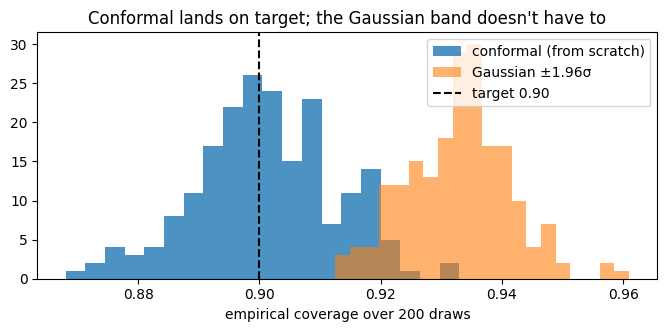

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(conf_cov, bins=20, alpha=0.8, label="conformal (from scratch)")
ax.hist(gauss_cov, bins=20, alpha=0.6, label="Gaussian ±1.96σ")
ax.axvline(0.9, color="black", ls="--", label="target 0.90")
ax.set_xlabel("empirical coverage over 200 draws"); ax.legend(); ax.set_title("Conformal lands on target; the Gaussian band doesn't have to")
plt.show()

---

### ✋ Quick exercise (~2 min) — Tighten the band to 95%

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Your SLA team now wants a **95%** guarantee instead of 90%. Using the `split_conformal_band` helper from §2, build the band at `alpha = 0.05`, confirm its empirical coverage on the test set, and see how much wider its half-width is than the 90% `qhat`.

```python
alpha_new = 0.05
```

In [7]:
# ✍️ Your turn 👇
# Reuse split_conformal_band(model, X_cal, y_cal, alpha) and `pred` from §2.
# Build the band at alpha=0.05, then compute its empirical coverage on the test set
# and compare its half-width to the 90% band's qhat.
q95 = ...


<details>
<summary>✅ <b>Solution</b></summary>

```python
q95 = split_conformal_band(model, X_cal, y_cal, 0.05)
cov95 = np.mean((y_te >= pred - q95) & (y_te <= pred + q95))
print(f"q̂(95%) = {q95:.3f}   vs   q̂(90%) = {qhat:.3f}")
print(f"empirical coverage = {cov95:.1%}")
```

Demanding more coverage raises the quantile level, so `q̂` grows and the band gets wider — coverage is always bought with width, never for free.
</details>

## 3. The adaptivity problem — a constant band is honest but blunt

The `±q̂` band has the **same width everywhere**. On our fan-shaped data that's a poor deal: it's *too wide* for short, easy trips and *too narrow* for long, volatile ones — even though the *marginal* coverage is correct. Marginal coverage ("90% overall") can hide terrible **conditional** coverage ("99% on easy points, 75% on hard ones").

The fix is to let the band **breathe with local difficulty**. The cleanest, most popular way is **Conformalized Quantile Regression (CQR)** (Romano, Patterson & Candès, 2019):

1. Train two **quantile** regressors for the low (α/2) and high (1−α/2) quantiles — these already *try* to be adaptive but carry no guarantee.
2. **Conformalize** them: on the calibration set, measure how far the truth falls *outside* the predicted `[q̂_lo, q̂_hi]`, and pad by the right quantile of that error.

You keep the guarantee **and** get bands that widen where the world is noisy.

In [8]:
# CQR from scratch: two quantile models + a conformal correction. Bands now ADAPT.
lo_model = GradientBoostingRegressor(loss="quantile", alpha=0.05, random_state=0).fit(X_tr, y_tr)
hi_model = GradientBoostingRegressor(loss="quantile", alpha=0.95, random_state=0).fit(X_tr, y_tr)

# conformity score = how far y is OUTSIDE the predicted quantile interval (signed, max of both sides)
cal_lo, cal_hi = lo_model.predict(X_cal), hi_model.predict(X_cal)
E = np.maximum(cal_lo - y_cal, y_cal - cal_hi)
n = len(E)
qhat_cqr = np.quantile(E, min(np.ceil((n + 1) * (1 - alpha)) / n, 1.0), method="higher")

te_lo = lo_model.predict(X_te) - qhat_cqr            # widen the quantile band by the correction
te_hi = hi_model.predict(X_te) + qhat_cqr
cov_cqr = np.mean((y_te >= te_lo) & (y_te <= te_hi))
print(f"CQR coverage = {cov_cqr:.1%}   ·   mean width = {(te_hi - te_lo).mean():.3f}  (vs constant {2*qhat:.3f})")


CQR coverage = 91.4%   ·   mean width = 4.199  (vs constant 5.606)


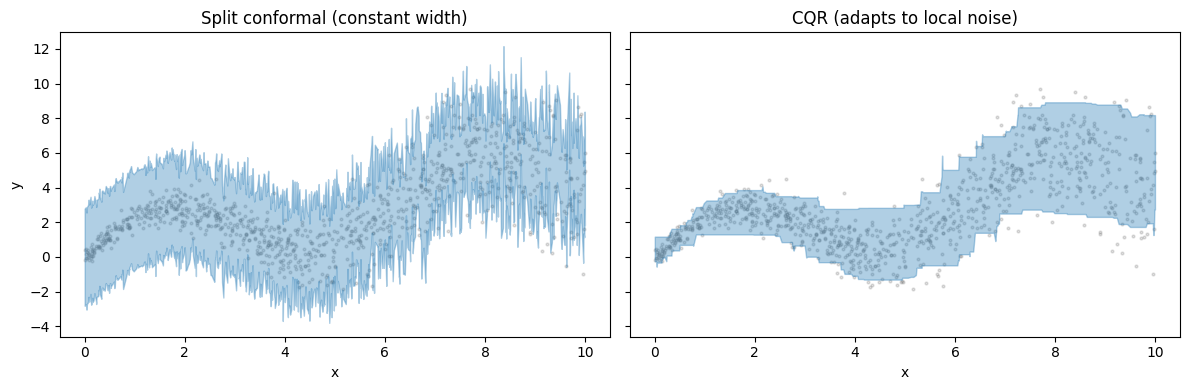

Both cover ~90% — but CQR spends its width where the noise actually is.


In [9]:
# Visualise: constant conformal band vs adaptive CQR band, sorted by x.
order = np.argsort(X_te.ravel()); xs = X_te.ravel()[order]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (name, lo_b, hi_b) in zip(axes, [("Split conformal (constant width)", pred - qhat, pred + qhat),
                                         ("CQR (adapts to local noise)", te_lo, te_hi)]):
    ax.scatter(X_te.ravel(), y_te, s=4, alpha=0.25, color="grey")
    ax.fill_between(xs, lo_b[order], hi_b[order], alpha=0.35, color="C0")
    ax.set_title(name); ax.set_xlabel("x")
axes[0].set_ylabel("y"); plt.tight_layout(); plt.show()
print("Both cover ~90% — but CQR spends its width where the noise actually is.")

> 🧠 **Mental model — coverage is the constraint, width is the objective.** *Every* valid conformal method hits the coverage target; they compete on **how narrow** they are and **how evenly** they cover across the input space. Split-conformal = simplest, constant width. CQR = adaptive width via quantile models. "Normalized" conformal (divide the score by a learned difficulty estimate σ̂(x)) is a third common route to adaptivity. Pick the one whose *bands* are tightest where you make decisions.

---

### ✋ Quick exercise (~2 min) — Does CQR really breathe?

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

The claim is that CQR widens where the world is noisy. Check it: using the CQR bands `te_lo` / `te_hi` you just built, compare the **mean interval width** on easy short trips (`x < 2`) versus hard long trips (`x > 8`). If CQR is adaptive, the long-trip band should be much wider.

In [10]:
# ✍️ Your turn 👇
# Use the CQR bands te_lo / te_hi from §3 and X_te.
# Compute the mean interval width (te_hi - te_lo) for easy short trips (x < 2)
# and for hard long trips (x > 8), and compare.


<details>
<summary>✅ <b>Solution</b></summary>

```python
x = X_te.ravel()
w = te_hi - te_lo
print(f"mean CQR width — short trips x<2 (easy): {w[x < 2].mean():.3f}")
print(f"mean CQR width — long trips  x>8 (hard): {w[x > 8].mean():.3f}")
```

The CQR band is far wider in the high-noise long-trip region and tight where trips are predictable — it spends its width where the uncertainty actually is, which a constant `±q̂` band cannot do.
</details>

## 4. Classification — prediction *sets*, not a single label

For classification the output is a **set of labels** guaranteed to contain the truth ≥ 1−α of the time. The set's **size is the model's honesty**: a confident, easy example → a singleton `{churn}`; a genuinely ambiguous one → `{churn, stay}` or larger. That is far more actionable than a bare `argmax` that's wrong 1-in-3 times with no warning.

The simplest score is **LAC** (Least Ambiguous set-valued Classifier, a.k.a. score = `1 − p̂(true class)`):

1. On calibration, score each point by `1 − softmax probability it gave the *true* class`.
2. Take the usual conformal quantile `q̂`.
3. New point's set = **every class whose probability ≥ 1 − q̂**.

In [11]:
# Split-conformal classification (LAC) from scratch on a 3-class problem.
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier

Xc, yc = make_classification(n_samples=6000, n_features=12, n_informative=6,
                             n_classes=3, n_clusters_per_class=2, class_sep=0.9,
                             random_state=0)
Xtr, Xtmp, ytr, ytmp = train_test_split(Xc, yc, test_size=0.5, random_state=0)
Xca, Xte2, yca, yte2 = train_test_split(Xtmp, ytmp, test_size=0.5, random_state=0)

clf = RandomForestClassifier(n_estimators=300, random_state=0).fit(Xtr, ytr)


In [12]:
proba_cal = clf.predict_proba(Xca)
scores = 1 - proba_cal[np.arange(len(yca)), yca]        # nonconformity of the TRUE label
n = len(scores)
qhat_cls = np.quantile(scores, min(np.ceil((n + 1) * (1 - alpha)) / n, 1.0), method="higher")

proba_te = clf.predict_proba(Xte2)
pred_sets = proba_te >= (1 - qhat_cls)                   # boolean matrix: which classes are IN the set
coverage = pred_sets[np.arange(len(yte2)), yte2].mean()  # is the true label in its set?
set_sizes = pred_sets.sum(axis=1)

print(f"q̂ = {qhat_cls:.3f}")
print(f"marginal coverage  = {coverage:.1%}   (target {1-alpha:.0%})")
print(f"average set size   = {set_sizes.mean():.2f} labels   (1 = confident, 3 = 'no idea')")
print(f"singletons {np.mean(set_sizes==1):.0%} · pairs {np.mean(set_sizes==2):.0%} · triples {np.mean(set_sizes==3):.0%}")
# The top-1 accuracy on the SAME points, for contrast:
print(f"plain argmax accuracy = {(clf.predict(Xte2)==yte2).mean():.1%} (no warning when it's wrong)")

q̂ = 0.653
marginal coverage  = 90.0%   (target 90%)
average set size   = 1.14 labels   (1 = confident, 3 = 'no idea')
singletons 86% · pairs 14% · triples 0%
plain argmax accuracy = 84.3% (no warning when it's wrong)


📊 **The honesty signal, made visual** — how often the model returns a confident singleton vs. an ambiguous multi-label set.

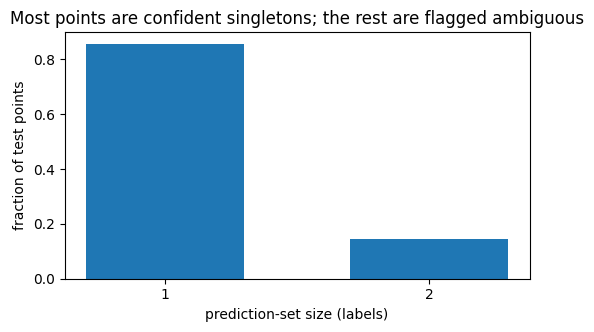

In [13]:
# Set size = honesty: how many test points get 1, 2, or 3 labels.
sizes, counts = np.unique(set_sizes, return_counts=True)
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(sizes, counts / counts.sum(), color="C0", width=0.6)
ax.set_xticks(sizes); ax.set_xlabel("prediction-set size (labels)")
ax.set_ylabel("fraction of test points")
ax.set_title("Most points are confident singletons; the rest are flagged ambiguous")
plt.show()

> ⚠️ **Marginal ≠ conditional coverage.** The guarantee is *marginal*: 90% **averaged over all inputs**. It does **not** promise 90% for each class or each subgroup — a model can hit 90% overall while covering one segment 98% and another 80%. When fairness or per-segment risk matters, use **Mondrian / class-conditional conformal**: run a *separate* calibration quantile *within each group*. That buys per-group coverage at the cost of needing enough calibration data per group. (You'll build this in Exercise 2.)

> 💡 **Beyond LAC: APS / RAPS.** LAC gives the *smallest* sets but can under-cover hard regions. **APS** (Adaptive Prediction Sets) accumulates sorted probabilities until they pass the threshold — larger sets, better *conditional* coverage. **RAPS** regularises APS to keep sets from blowing up on many-class problems. MAPIE exposes all three via `conformity_score=`.

---

### ✋ Quick exercise (~2 min) — How many cases need a human?

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Your churn triage system auto-decides only the **confident singletons** and routes everything ambiguous to a human reviewer. Using `set_sizes` from §4, compute the fraction of test customers whose prediction set is **not** a singleton (i.e. `size > 1`) — that's your human review queue.

In [14]:
# ✍️ Your turn 👇
# set_sizes (from §4) holds the prediction-set size for each test point.
# Compute the fraction of customers whose set is NOT a singleton (size > 1).


<details>
<summary>✅ <b>Solution</b></summary>

```python
route = np.mean(set_sizes > 1)
print(f"routed to a human (set size > 1): {route:.1%}")
print(f"auto-decided singletons:         {np.mean(set_sizes == 1):.1%}")
```

The non-singleton sets are exactly the ambiguous customers conformal flags for review — instead of letting `argmax` guess silently and be wrong with no warning, you triage them to a human.
</details>

## 5. Time series & distribution shift — when the guarantee breaks

Everything above rested on **exchangeability**. Time series violate it twice over: observations are **autocorrelated** (today depends on yesterday) and the distribution **drifts** (last quarter's calibration no longer describes this quarter). Apply plain split-conformal to a forecast and your coverage silently rots as the world moves.

Two repairs are standard:

- **EnbPI** (Ensemble Batch Prediction Intervals, Xu & Xie 2021): bootstrap an ensemble, use *leave-one-out* residuals as the conformity scores, and slide the calibration window forward as new actuals arrive. No data splitting; built for sequential data.
- **ACI** (Adaptive Conformal Inference, Gibbs & Candès 2021): don't fix α — **adjust it online**. Whenever you *miss*, widen; whenever you *cover*, tighten. This chases the *long-run* target coverage even under arbitrary drift, with no distributional assumption at all.

ACI is short enough to write from scratch — and watching it defend its coverage target through a regime change is the whole lesson.

In [15]:
# ACI from scratch vs a FIXED conformal band, on a series whose noise SHIFTS partway through.
T = 2000
t = np.arange(T)
sig = np.where(t < T // 2, 1.0, 4.0)                     # variance JUMPS 4x at the midpoint
series = 10 + np.sin(t / 20) + np.random.default_rng(1).normal(0, sig)

# A trivial "forecaster": predict the previous value. Residual = |y_t - y_{t-1}|.
resid = np.abs(np.diff(series))
target = 0.10                                            # want ~90% coverage


In [16]:
# (1) FIXED band: calibrate q once on the first 300 residuals, then freeze it.
q_fixed = np.quantile(resid[:300], 1 - target, method="higher")
fixed_cov = (resid[300:] <= q_fixed)

# (2) ACI: alpha_t adapts; gamma is the learning rate.
gamma, a_t = 0.02, target
aci_hits, widths = [], []
window = list(resid[:300])
for r in resid[300:]:
    lvl = min(max(1 - a_t, 0.0), 1.0)
    q_t = np.quantile(window[-300:], lvl, method="higher")  # band from recent residuals at adapted level
    covered = r <= q_t
    aci_hits.append(covered); widths.append(q_t)
    a_t = a_t + gamma * (target - (0 if covered else 1))    # miss -> a_t down -> wider next time
    window.append(r)

def rolling(x, w=200): x = np.asarray(x, float); return np.convolve(x, np.ones(w)/w, "valid")
print(f"FIXED band  long-run coverage = {fixed_cov.mean():.1%}  (drifts after the shift)")
print(f"ACI         long-run coverage = {np.mean(aci_hits):.1%}  (defends the 90% target)")


FIXED band  long-run coverage = 55.0%  (drifts after the shift)
ACI         long-run coverage = 90.0%  (defends the 90% target)


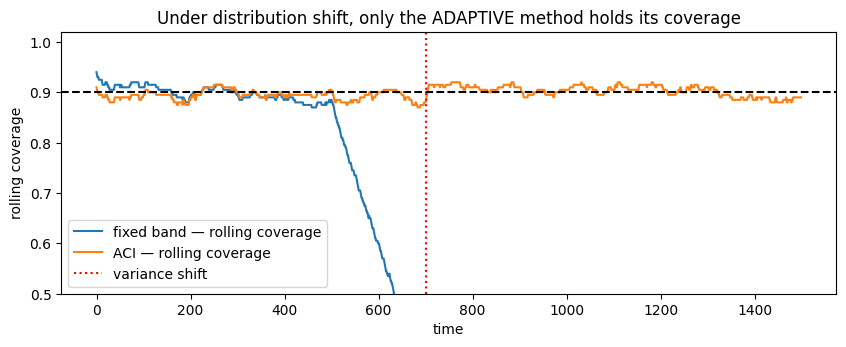

In [17]:
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(rolling(fixed_cov), label="fixed band — rolling coverage")
ax.plot(rolling(aci_hits), label="ACI — rolling coverage")
ax.axvline(T // 2 - 300, color="red", ls=":", label="variance shift")
ax.axhline(0.9, color="black", ls="--"); ax.set_ylim(0.5, 1.02)
ax.set_xlabel("time"); ax.set_ylabel("rolling coverage"); ax.legend(loc="lower left")
ax.set_title("Under distribution shift, only the ADAPTIVE method holds its coverage"); plt.show()

---

### ✋ Quick exercise (~2 min) — Was the fixed band ever fine?

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

The fixed band's long-run coverage was only ~55%, but that average hides the regime change. Confirm it actually covered well **before** the variance jump: compute `fixed_cov`'s mean over just its first 700 steps (the low-noise era) and compare it to the mean over the rest.

In [18]:
# ✍️ Your turn 👇
# fixed_cov (from §5) is a boolean array of per-step coverage for the FIXED band,
# starting 300 steps in. The variance shift lands ~700 steps into fixed_cov.
# Compare the fixed band's mean coverage over the first 700 steps vs the rest.


<details>
<summary>✅ <b>Solution</b></summary>

```python
print(f"fixed band coverage, pre-shift  (first 700): {fixed_cov[:700].mean():.1%}")
print(f"fixed band coverage, post-shift (rest):      {fixed_cov[700:].mean():.1%}")
```

Before the jump the frozen `q̂` matched the data and covered ~90%; it only collapses afterward because the variance change broke exchangeability — which is precisely why ACI's online α is needed to keep up.
</details>

## 6. The packages — what you'd actually use in production

You now understand the machinery, so the libraries are just convenience + speed + breadth of scores. **MAPIE** is the de-facto standard (scikit-learn-contrib, sklearn-compatible). Its v1 API splits the work into an explicit **fit → conformalize → predict** flow.

```python
# ── MAPIE (v1) reference — regression ────────────────────────────────────
# pip install mapie
from mapie.regression import SplitConformalRegressor
from mapie.utils import train_conformalize_test_split
from sklearn.ensemble import RandomForestRegressor

(X_train, X_conf, X_test,
 y_train, y_conf, y_test) = train_conformalize_test_split(
     X, y, train_size=0.6, conformalize_size=0.2, test_size=0.2, random_state=0)

scr = SplitConformalRegressor(
    estimator=RandomForestRegressor(random_state=0),
    confidence_level=0.9,            # == 1 - alpha
    conformity_score="absolute",     # the |y - ŷ| score we coded by hand
    prefit=False,
)
scr.fit(X_train, y_train)            # fit the base model
scr.conformalize(X_conf, y_conf)     # compute q̂ on the calibration set
y_pred, y_interval = scr.predict_interval(X_test)   # point + [lower, upper]
```

```python
# ── MAPIE (v1) reference — CQR & classification ──────────────────────────
from mapie.regression import ConformalizedQuantileRegressor   # adaptive bands (our §3)
from mapie.classification import SplitConformalClassifier      # prediction sets (our §4)

scc = SplitConformalClassifier(estimator=clf, confidence_level=0.9,
                               conformity_score="lac", prefit=True)   # "aps"/"raps" also available
scc.conformalize(X_conf, y_conf)
y_pred, y_sets = scc.predict_set(X_test)            # y_sets is a boolean (n, n_classes) mask
```

```python
# ── MAPIE — time series (EnbPI / ACI), our §5 ────────────────────────────
from mapie.regression import TimeSeriesRegressor    # EnbPI + adaptive (partial_fit) updating
# enbpi.predict(X, alpha=0.1, ensemble=True); then enbpi.partial_fit(X_new, y_new) as actuals arrive
```

**The wider landscape** (same idea, different ergonomics):

| Package | `pip install` | Sweet spot |
|---|---|---|
| **MAPIE** | `mapie` | The default. sklearn API, regression + classification + time series, all scores. |
| **crepes** | `crepes` | Minimal & fast; "conformal regressors and predictive systems"; great for research. |
| **puncc** | `puncc` | Deel's library; CQR, EnbPI, split/cross, clean abstractions. |
| **TorchCP** | `torchcp` | Conformal for **deep learning** (PyTorch) — classification, regression, graphs. |
| **conformal-tights / fortuna** | `conformal-tights` / `fortuna` | Drop-in sklearn wrappers / AWS's Bayesian+conformal toolkit. |

## 7. When to reach for it — and the traps

**Reach for conformal prediction when** a wrong prediction is *costly* and you must *act on the uncertainty*: triage (only auto-decide singletons, route ambiguous sets to a human), risk-aware forecasting (size buffers from the upper bound), selective prediction, LLM output filtering, A/B guardrails.

```text
Need a guaranteed band around ANY regressor?        →  split conformal  (constant width)
…and the noise varies across the input?             →  CQR  or  normalized conformal
Need label sets with a coverage guarantee?          →  conformal classification (LAC / APS / RAPS)
Per-group / per-class coverage (fairness)?          →  Mondrian (class-conditional) conformal
Sequential data / drift?                            →  EnbPI  or  ACI  (NOT plain split conformal)
Tiny dataset, can't spare a calibration split?      →  cross-conformal (CV+) / Jackknife+
```

> ⚠️ **The four traps.**
> 1. **Exchangeability is the whole contract.** Time order, distribution shift, or a calibration set drawn differently from production → the guarantee is void. Use the §5 methods, and *monitor* realised coverage in production.
> 2. **Leakage kills it.** The calibration set must be **untouched** by training (incl. feature selection & hyper-parameter tuning). Reuse training data and you'll *over*-state coverage.
> 3. **Marginal, not conditional.** 90% overall ≠ 90% for your most important segment (see §4 warning).
> 4. **Calibration size sets the resolution.** With n calibration points the achievable levels are coarse (steps of ~1/n); ~1000 points is comfortable for α = 0.1.

## 🧪 Exercises

### Exercise 1 — Does coverage really track 1 − α?
Sweep `alpha` over `[0.20, 0.10, 0.05, 0.01]` with the §2 split-conformal band and confirm empirical coverage rises with the target — and that the bands get **wider** as you demand more coverage.

In [19]:
# ── Exercise 1 solution ──────────────────────────────────────────────────
print(f"{'alpha':>6} {'target':>8} {'coverage':>10} {'half-width':>11}")
for a in [0.20, 0.10, 0.05, 0.01]:
    q = split_conformal_band(model, X_cal, y_cal, a)
    cov = np.mean((y_te >= pred - q) & (y_te <= pred + q))
    print(f"{a:>6} {1-a:>8.0%} {cov:>10.1%} {q:>11.3f}")
print("\nHigher target coverage  ->  higher q̂  ->  wider bands. No free lunch.")

 alpha   target   coverage  half-width
   0.2      80%      82.8%       2.044
   0.1      90%      91.4%       2.803
  0.05      95%      95.8%       3.534
  0.01      99%      99.6%       4.994

Higher target coverage  ->  higher q̂  ->  wider bands. No free lunch.


### Exercise 2 — Mondrian (class-conditional) coverage
The §4 sets give 90% **marginal** coverage, but the **per-class** coverage varies (one class is over-covered, another under). Compute it, then calibrate a **separate** quantile `q̂_k` *within each class k* so each class **targets** 90% (the guarantee is now per-class, in expectation). Watch the worst class improve and the spread tighten — the residual wobble is just finite-sample noise on ~300 points per class.

In [20]:
# ── Exercise 2 solution ──────────────────────────────────────────────────
# (a) per-class coverage of the single-q̂ (marginal) sets from §4:
print("Marginal (single q̂) — per-class coverage:")
for k in range(3):
    m = yte2 == k
    print(f"  class {k}: {pred_sets[m][np.arange(m.sum()), k].mean():.1%}")

# (b) Mondrian: a separate calibration quantile within each true class.
qhat_k = {}
for k in range(3):
    s_k = scores[yca == k]                                  # calib scores for true class k only
    nk = len(s_k)
    qhat_k[k] = np.quantile(s_k, min(np.ceil((nk + 1) * (1 - alpha)) / nk, 1.0), method="higher")

# Build sets: class c is included if (1 - p_c) <= q̂_c  (each class uses its OWN threshold)
thresh = np.array([1 - qhat_k[c] for c in range(3)])        # per-class probability floor
mondrian_sets = proba_te >= thresh
print("\nMondrian (per-class q̂) — per-class coverage:")
for k in range(3):
    m = yte2 == k
    print(f"  class {k}: {mondrian_sets[m][np.arange(m.sum()), k].mean():.1%}  (q̂={qhat_k[k]:.3f})")
print(f"\navg set size: marginal {pred_sets.sum(1).mean():.2f}  ->  Mondrian {mondrian_sets.sum(1).mean():.2f}")
print("Per-class coverage is now balanced around 90% (each class uses its own q̂).")

Marginal (single q̂) — per-class coverage:
  class 0: 92.5%
  class 1: 86.4%
  class 2: 91.1%

Mondrian (per-class q̂) — per-class coverage:
  class 0: 92.1%  (q̂=0.647)
  class 1: 88.6%  (q̂=0.687)
  class 2: 89.3%  (q̂=0.623)

avg set size: marginal 1.14  ->  Mondrian 1.15
Per-class coverage is now balanced around 90% (each class uses its own q̂).


## 🧠 Key takeaways

- **Conformal prediction wraps any model** and returns intervals/sets with a **finite-sample, distribution-free coverage guarantee** — the promise calibration *can't* make.
- The engine is one line: **the right quantile of nonconformity scores on a clean calibration set.** The `⌈(n+1)(1−α)⌉/n` correction turns "≈" into a theorem.
- **Coverage is guaranteed; width is the quality metric.** A bad model gets valid-but-wide bands. **CQR** / normalized scores make bands **adapt** to local difficulty.
- In classification you get **prediction sets**, and **set size = honesty.** Watch **marginal vs conditional** coverage; use **Mondrian** for per-group guarantees.
- **Exchangeability is the one assumption.** Time series & drift break it — reach for **EnbPI / ACI**, and monitor realised coverage in production.
- In practice: **MAPIE** first (`fit → conformalize → predict_interval/predict_set`); **crepes / puncc / TorchCP** for lightweight, research, or deep-learning needs.

## 🚀 Next step

Bring the guarantee to your forecasts: revisit **`../02_data_science/11_time_series_forecasting.ipynb`** (§13 ecosystem tour) and wrap one of those models in ACI, or pair this with **Notebook 18** to ship a churn model that *abstains* (returns a set, routes ambiguous cases to a human) instead of guessing.